In [1]:
import pandas as pd

In [2]:
radiomics_df = pd.read_csv("../cross_eval/abdomen_atlas_pro/radiomics_metrics.csv")

In [3]:
list(radiomics_df.columns)

['bdmap_id',
 'organ',
 'component_id',
 'num_components',
 'diameter_x_mm',
 'diameter_y_mm',
 'diameter_z_mm',
 'attenuation_delta',
 'original_firstorder_10Percentile',
 'original_firstorder_90Percentile',
 'original_firstorder_Energy',
 'original_firstorder_Entropy',
 'original_firstorder_InterquartileRange',
 'original_firstorder_Kurtosis',
 'original_firstorder_Maximum',
 'original_firstorder_Mean',
 'original_firstorder_MeanAbsoluteDeviation',
 'original_firstorder_Median',
 'original_firstorder_Minimum',
 'original_firstorder_Range',
 'original_firstorder_RobustMeanAbsoluteDeviation',
 'original_firstorder_RootMeanSquared',
 'original_firstorder_Skewness',
 'original_firstorder_TotalEnergy',
 'original_firstorder_Uniformity',
 'original_firstorder_Variance',
 'original_glcm_Autocorrelation',
 'original_glcm_ClusterProminence',
 'original_glcm_ClusterShade',
 'original_glcm_ClusterTendency',
 'original_glcm_Contrast',
 'original_glcm_Correlation',
 'original_glcm_DifferenceAvera

In [7]:
radiomics_df = radiomics_df[radiomics_df["original_shape_LeastAxisLength"]>0.0]

In [4]:
radiomics_df = radiomics_df.dropna()

In [5]:
from sklearn.manifold import TSNE

In [6]:
dim_red = TSNE(n_components=2)

In [8]:
features_to_ignore = ["bdmap_id", "organ", "component_id","num_components"]

In [9]:
all_numerical_features = [x for x in list(radiomics_df.columns) if x not in features_to_ignore]

In [10]:
df_numerical = radiomics_df[all_numerical_features]

In [11]:
transformed = dim_red.fit_transform(df_numerical)

In [12]:
import seaborn as sns

In [13]:
from matplotlib import pyplot as plt

In [14]:
x = transformed[:,0]
y = transformed[:,1]

In [15]:
radiomics_df["x"] = x
radiomics_df["y"] = y

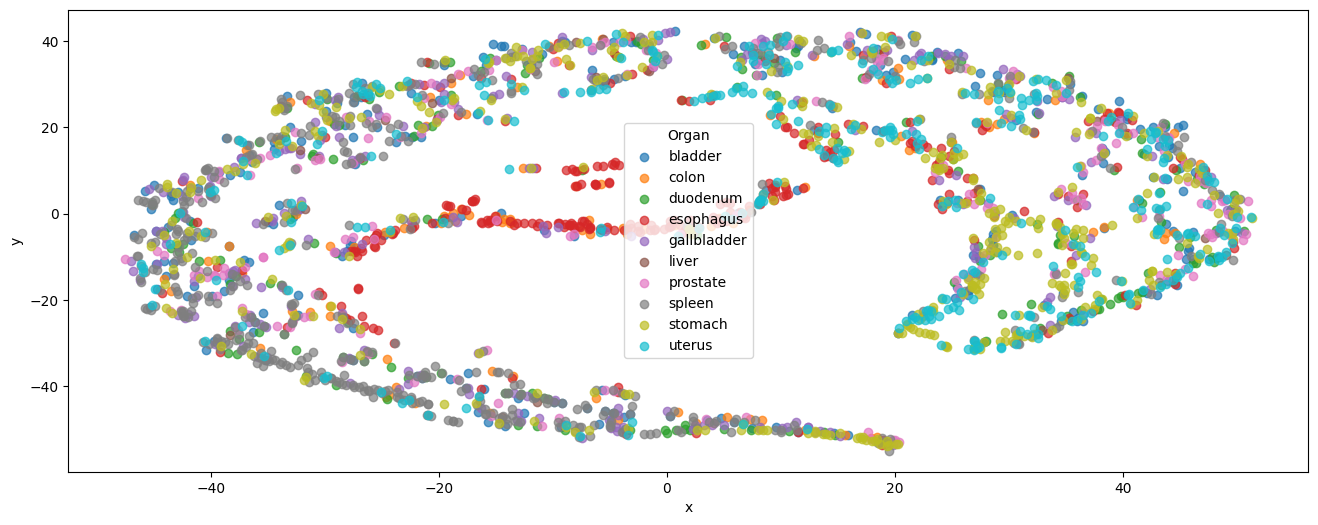

In [16]:
plt.figure(figsize=(16, 6))

for organ, group in radiomics_df.groupby("organ"):
    plt.scatter(group["x"], group["y"], label=organ, alpha=0.7)

plt.xlabel("x")
plt.ylabel("y")
plt.legend(title="Organ")
plt.show()

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer


In [20]:
import pickle
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm
import numpy as np

gmm_bank = {}

for organ, group in tqdm(radiomics_df.groupby("organ")):

    X = group[all_numerical_features]

    # preprocessing
    pt = PowerTransformer(method="yeo-johnson")
    X = pt.fit_transform(X)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # reduce dimensionality
    pca = PCA(n_components=0.95, random_state=42)
    X = pca.fit_transform(X)

    # select components by BIC
    best_gmm = None
    best_bic = np.inf

    for k in range(1, 11):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="diag",   # safer for <500 samples
            random_state=42
        )
        gmm.fit(X)
        bic = gmm.bic(X)

        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    gmm_bank[organ] = {
        "gmm": best_gmm,
        "power_transformer": pt,
        "scaler": scaler,
        "pca": pca,
        "feature_names": list(all_numerical_features),  # column order used to fit
        "bic": best_bic,
    }


100%|██████████| 10/10 [00:03<00:00,  2.85it/s]


In [21]:

# save
save_path = "gmm_bank.pkl"
with open(save_path, "wb") as f:
    pickle.dump(gmm_bank, f)

print(f"Saved GMM bank for {len(gmm_bank)} organs to {save_path}")

Saved GMM bank for 10 organs to gmm_bank.pkl


In [197]:
organ = "esophagus"
n_samples = 10000

gmm = gmm_models[organ]
prep = preprocessors[organ]

X_new, cluster = gmm.sample(n_samples)

# undo PCA/scaling/transformation
X_new = prep["pca"].inverse_transform(X_new)
X_new = prep["scaler"].inverse_transform(X_new)
X_new = prep["power_transformer"].inverse_transform(X_new)

samples = pd.DataFrame(
    X_new,
    columns=all_numerical_features
)

/home/rpinise1/.conda/envs/synth-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


In [198]:
samples.dropna(inplace=True)

In [199]:
import umap

In [200]:
visualize = umap.UMAP(n_components=2)

In [201]:
synth_plus_real = pd.concat([df_numerical, samples], axis=0)

In [202]:
organ_column = list(radiomics_df["organ"]) + list([f"{organ}_synth" for i in range(samples.shape[0])])

In [203]:
umap_df_transformed = visualize.fit_transform(df_numerical)

In [204]:
data_to_plot = df_numerical.copy()

In [205]:
data_to_plot["x"] = umap_df_transformed[:,0]
data_to_plot["y"] = umap_df_transformed[:,1]

In [206]:
data_to_plot["organ"] = radiomics_df["organ"]

In [208]:
transformed_synthetic = visualize.transform(samples[:1000])

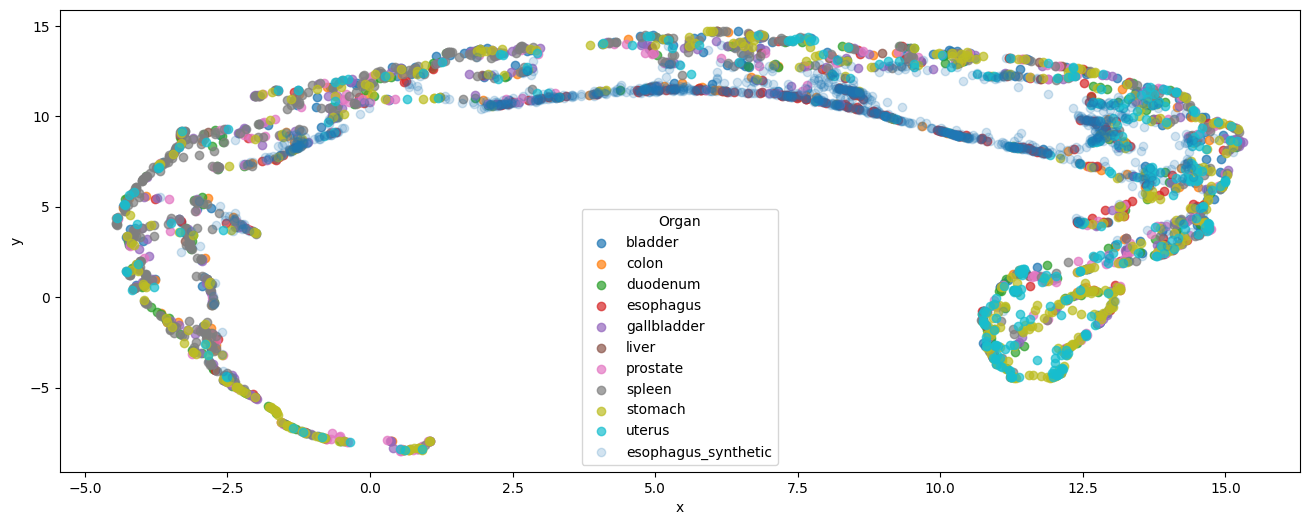

In [214]:
plt.figure(figsize=(16, 6))

for organ_name, group in data_to_plot.groupby("organ"):
    plt.scatter(group["x"], group["y"], label=organ_name, alpha=0.7)

plt.scatter(transformed_synthetic[:,0],transformed_synthetic[:,1], label=f"{organ}_synthetic", alpha=0.2)

plt.xlabel("x")
plt.ylabel("y")
plt.legend(title="Organ")
plt.show()

In [ ]:
import pickle

In [ ]:
from utils import *